# Sistema Inteligente de Soporte Hospitalario
## laSalle Health Center

**Alejandro Marinas · Yago Alonso**  
Máster en AI & Big Data · laSalle

---

Este notebook recorre el proyecto **de principio a fin**, ejecutando código real y mostrando dónde vive cada parte del sistema.

**Estructura**:

1. Visión general del proyecto
2. Arquitectura del sistema
3. Los datos
4. El pipeline (PySpark)
5. El modelo CNN
6. La regla `covid_threshold_0.35`
7. El triaje por reglas
8. La automatización
9. El dashboard
10. Logs y trazabilidad
11. Tests automatizados
12. Ética y limitaciones
13. Trabajo futuro


In [1]:
# Setup: añadir el directorio raíz al path
import sys, os
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f'Raíz del proyecto: {PROJECT_ROOT}')
print(f'¿Existe src/? {(PROJECT_ROOT / "src").exists()}')
print(f'¿Existe data/? {(PROJECT_ROOT / "data").exists()}')
print(f'¿Existe docs/? {(PROJECT_ROOT / "docs").exists()}')

Raíz del proyecto: /Users/alejandromarinas/Documents/practica_final
¿Existe src/? True
¿Existe data/? True
¿Existe docs/? True


---
## 1. Visión general del proyecto

### Qué construimos

Un sistema completo para el hospital ficticio **laSalle Health Center** que resuelve **tres problemas operativos del cliente**:

1. **No podían extraer conocimiento** de sus datos clínicos.
2. **No automatizaban procesos** repetitivos (ingesta, validación, informes).
3. **No tenían soporte al turno** — el operador iba a ciegas, sin un panel que le dijera *"¿qué requiere mi atención ahora?"*.

### La línea ética desde el día uno

> **Ayudamos al médico. NO le sustituimos.**

La decisión clínica la mantiene siempre el profesional sanitario. No es un disclaimer al final — es lo que condiciona cada decisión técnica del proyecto. Formalizado en `CLAUDE.md`.

### Lo que pedía el enunciado vs lo que entregamos

| Eje del enunciado | Mínimo pedido | Entregado |
|---|---|---|
| Tipos de almacenamiento | ≥ 2 | **3** (MongoDB + SQLite + MinIO) |
| Paradigmas de IA | ≥ 1 | **2** (CNN custom + reglas IF-THEN) |
| Mecanismos de automatización | 1+ | **4** (informes, alertas, watcher, ingester) |
| Framework distribuido | 1 | **PySpark** |
| API REST documentada | sí | **FastAPI** + Swagger, 17 endpoints |
| Dashboard con visualización | sí | **Streamlit**, 7 vistas |
| Despliegue con un solo comando | sí | `docker compose up` (< 1 min) |
| Vibe Coding + SDD + diario IA | obligatorio | **6 specs · 10 ADRs · 31 sesiones IA** |


In [2]:
# Confirmar las cifras del proyecto en directo
specs_dir = PROJECT_ROOT / 'specs'
decisions_dir = PROJECT_ROOT / 'decisions'

n_specs = len([f for f in specs_dir.glob('*.md') if f.is_file()])
n_adrs = len([f for f in decisions_dir.glob('ADR-*.md') if f.is_file()])

print(f'Specs aprobadas:  {n_specs}')
print(f'ADRs escritos:    {n_adrs}')
print(f'Sesiones IA:      31 (en docs/diario-ia.md)')

Specs aprobadas:  6
ADRs escritos:    10
Sesiones IA:      31 (en docs/diario-ia.md)


---
## 2. Arquitectura del sistema

**Siete servicios Docker, un solo comando.** Se lee de izquierda a derecha en 4 pasos:

1. **ENTRA** — 3 fuentes de datos: CSV pacientes, CSV admisiones, radiografías PNG.
2. **PROCESA** — el pipeline PySpark valida, deduplica, enriquece.
3. **GUARDA** — cada tipo de dato en su almacén:
   - **MongoDB** → pacientes con admisiones embebidas (datos jerárquicos)
   - **SQLite** → auditoría del pipeline (`pipeline_runs`, `data_quality_summary`)
   - **MinIO** → radiografías PNG (binarios)
4. **SIRVE** — FastAPI sirve todo, Streamlit consume *solo* la API (API-only, ADR-007).

**ADRs relacionados**: ADR-001 (stack), ADR-002 (MongoDB), ADR-004 (polyglot persistence), ADR-006 (imagen Docker compartida), ADR-007 (dashboard separado).

In [3]:
# Los 7 servicios del docker-compose
import yaml

with open(PROJECT_ROOT / 'docker-compose.yml') as f:
    compose = yaml.safe_load(f)

servicios = list(compose.get('services', {}).keys())
print(f'Total servicios: {len(servicios)}\n')
for nombre in servicios:
    cfg = compose['services'][nombre]
    img = cfg.get('image', cfg.get('build', {}).get('context', '(custom)'))
    print(f'  · {nombre:20s} → {img}')

Total servicios: 7

  · mongodb              → mongo:7
  · minio                → minio/minio
  · minio-init           → minio/mc
  · pipeline             → hospital-pipeline:latest
  · api                  → hospital-pipeline:latest
  · watcher              → hospital-pipeline:latest
  · dashboard            → hospital-dashboard:latest


In [4]:
# Verificar que el sistema está corriendo AHORA
import requests

endpoints = {
    'API health':   'http://localhost:8000/api/v1/health',
    'Dashboard':    'http://localhost:8501/_stcore/health',
    'API docs':     'http://localhost:8000/docs',
    'MinIO consola':'http://localhost:9001',
}

for nombre, url in endpoints.items():
    try:
        r = requests.get(url, timeout=2)
        estado = '✅' if r.status_code < 400 else '❌'
    except Exception as e:
        estado = '❌ (no responde)'
    print(f'  {estado}  {nombre:20s} → {url}')

  ✅  API health           → http://localhost:8000/api/v1/health
  ✅  Dashboard            → http://localhost:8501/_stcore/health
  ✅  API docs             → http://localhost:8000/docs
  ✅  MinIO consola        → http://localhost:9001


/Users/alejandromarinas/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


---
## 3. Los datos

Manejamos **tres tipos de datos** y **tres almacenes distintos** porque cada tipo de dato vive donde mejor encaja.

### Datos clínicos sintéticos

Generados con `Faker` y semilla fija — **cero datos reales de pacientes** (decisión ética desde el día uno).

- `data/raw/patients.csv` — pacientes (demográficos)
- `data/raw/admissions.csv` — ingresos hospitalarios

### Imágenes médicas reales

**COVID-19 Radiography Database** de Kaggle, con licencia tal como el autor publica:

- `data/raw/covid_radiography/COVID-19_Radiography_Dataset/` → 15.150 radiografías de tórax en 3 clases (Normal, Pneumonia, COVID-19).

In [5]:
# Tamaño real de cada fuente
import csv

patients_csv = PROJECT_ROOT / 'data' / 'raw' / 'patients.csv'
admissions_csv = PROJECT_ROOT / 'data' / 'raw' / 'admissions.csv'

with open(patients_csv) as f:
    n_pacientes = sum(1 for _ in f) - 1  # menos cabecera
with open(admissions_csv) as f:
    n_admisiones = sum(1 for _ in f) - 1

print(f'CSV de pacientes:    {n_pacientes:,} filas')
print(f'CSV de admisiones:   {n_admisiones:,} filas')

# Conteo radiografías por clase
radio_dir = PROJECT_ROOT / 'data' / 'raw' / 'covid_radiography' / 'COVID-19_Radiography_Dataset'
if radio_dir.exists():
    print(f'\nDataset COVID-19 Radiography (Kaggle):')
    for clase in ['Normal', 'Viral Pneumonia', 'COVID']:
        imagenes = list((radio_dir / clase / 'images').glob('*.png')) if (radio_dir / clase / 'images').exists() else []
        print(f'  · {clase:18s} {len(imagenes):>5,} imágenes')
    print(f'\n  Total clasificación triple: ~15.150 imágenes')

CSV de pacientes:    5,150 filas
CSV de admisiones:   10,000 filas

Dataset COVID-19 Radiography (Kaggle):
  · Normal             10,192 imágenes
  · Viral Pneumonia    1,345 imágenes
  · COVID              3,616 imágenes

  Total clasificación triple: ~15.150 imágenes


In [6]:
# Mostrar una muestra de patients.csv
import pandas as pd

df_pacientes = pd.read_csv(patients_csv)
print(f'Shape: {df_pacientes.shape}')
print(f'Columnas: {list(df_pacientes.columns)}\n')
df_pacientes.head()

Shape: (5150, 5)
Columnas: ['external_id', 'name', 'birth_date', 'gender', 'blood_type']



,external_id,name,birth_date,gender,blood_type
0,HOSP-000000,Raimundo Llopis Hierro,1992-02-04,F,A+
1,HOSP-000001,Nilo Bonet Roca,1958-05-19,M,O+
2,HOSP-000002,César Guerrero Vazquez,1942-11-16,F,A+
3,HOSP-000003,Chita del Giménez,1989-01-23,M,A+
4,HOSP-000004,Sandalio Agudo-Cuervo,1976-09-07,M,A+


---
## 4. El pipeline (PySpark)

El pipeline es **la línea de montaje** que convierte los CSVs crudos en datos limpios guardados en sus almacenes.

### Las 4 etapas

1. **Lee** los CSVs con Spark
2. **Valida** cada fila (campos obligatorios, fechas correctas, IDs existentes)
3. **Quita duplicados** y **enriquece** (calcula edad, categoría diagnóstico)
4. **Guarda** en MongoDB / SQLite / MinIO

### Lo importante: ningún dato se pierde en silencio

Las filas que no pasan la validación NO se descartan — se guardan en `rejected_records` con su motivo y el dato crudo.

Si el % de rechazo supera el **10%**, salta una **alerta automática** (`data_quality_low`).

### Dónde vive el código

| Etapa | Archivo |
|---|---|
| Orquestador (director) | `src/pipeline/orchestrator.py` |
| Lectores CSV | `src/pipeline/ingesters/csv_ingester.py` |
| Validadores | `src/pipeline/processors/data_validator.py` |
| Limpieza + enriquecimiento | `src/pipeline/processors/data_cleaner.py`, `data_transformer.py` |
| Resumen de calidad | `src/pipeline/processors/quality_summary.py` |
| Escritura | `src/pipeline/storage/mongo_writer.py`, `sql_writer.py`, `minio_client.py` |
| Watcher automático | `src/pipeline/watcher.py` |

In [7]:
# Pedir a la API el resumen de calidad de datos del último run
import requests, json

try:
    r = requests.get('http://localhost:8000/api/v1/pipeline/quality-summary', timeout=3)
    if r.status_code == 200:
        data = r.json()
        if isinstance(data, list) and data:
            print('Resumen de calidad del último run:\n')
            for dim in data:
                total = dim.get('total_count', 0)
                validos = dim.get('valid_count', 0)
                rechazados = dim.get('rejected_count', 0)
                tasa = dim.get('rejection_rate', 0)
                print(f"  · {dim.get('dimension', '?'):20s} → {total:>5,} totales, {validos:>5,} válidos, {rechazados:>5,} rechazados ({tasa:.1%})")
        else:
            print('Respuesta vacía — quizá no ha habido pipeline run aún')
            print(json.dumps(data, indent=2)[:500])
    else:
        print(f'API status {r.status_code}')
except Exception as e:
    print(f'No se pudo consultar la API: {e}')
    print('(El sistema debe estar corriendo: docker compose up)')

Respuesta vacía — quizá no ha habido pipeline run aún
{
  "items": [
    {
      "pipeline_run_id": "12f89d07-b3aa-4fc4-8675-d407836702e1",
      "dimension": "admissions",
      "total": 9997,
      "valid": 8569,
      "rejected": 1428,
      "rejection_rate": 0.14284285285585677,
      "recorded_at": "2026-05-21T00:49:16.008560"
    },
    {
      "pipeline_run_id": "12f89d07-b3aa-4fc4-8675-d407836702e1",
      "dimension": "patients",
      "total": 5009,
      "valid": 4745,
      "rejected": 264,
      "rejection_rate": 0.05270513076462368,
 


---
## 5. El modelo CNN

Una **red neuronal convolucional hecha desde cero** que clasifica radiografías de tórax en 3 clases: Normal, Neumonía, COVID-19.

### ¿Qué es una CNN?

**CNN = Convolutional Neural Network** (Red Neuronal Convolucional). Es el tipo de modelo que la industria usa para **trabajar con imágenes**.

La idea: en vez de mirar cada píxel suelto, **la CNN aprende a detectar patrones locales** (bordes, texturas, formas) y los combina capa a capa hasta entender qué hay en la imagen.

Es como mirar tú una radiografía:

1. **Primero ves bordes** (¿dónde están los pulmones?)
2. **Luego texturas** (¿hay manchas raras?)
3. **Después patrones combinados** (¿hay un infiltrado típico de neumonía?)
4. **Al final clasificas** (Normal / Neumonía / COVID-19)

**Una CNN hace exactamente esto**, pero con miles de filtros entrenados sobre 12.120 ejemplos.

### Por qué CNN y no otro modelo

| Tipo de dato | Modelo natural |
|---|---|
| Tablas (signos vitales, CSVs) | Decision Tree, Random Forest |
| Texto | RNN, Transformers |
| **Imágenes** ✅ | **CNN** |

Las radiografías son imágenes → CNN es la elección correcta.

**Tres razones documentadas en ADR-005**:
1. **CNN es el modelo estándar de la industria para clasificación de imágenes** — arquitectura probada para este tipo de problema
2. Cabe en el **techo de 50 MB** del requisito no funcional (transfer learning pesaría 100-200 MB)
3. **Sin dependencias externas en el arranque** — el sistema arranca sin descargar pesos preentrenados de internet

### Nuestra arquitectura: 14 capas en 4 bloques + clasificador

**Cuatro bloques convolucionales** (cada uno mira la imagen a una escala diferente):

```
Imagen 224x224x1 (escala de grises)
       │
   ┌───▼─────────────────────────────────┐
   │ BLOQUE 1: Conv2D(32) + MaxPool      │  Detecta bordes y líneas
   └───┬─────────────────────────────────┘
       ▼ → 112x112
   ┌───────────────────────────────────────┐
   │ BLOQUE 2: Conv2D(64) + MaxPool      │  Detecta texturas
   └───┬─────────────────────────────────┘
       ▼ → 56x56
   ┌───────────────────────────────────────┐
   │ BLOQUE 3: Conv2D(128) + MaxPool     │  Detecta patrones combinados
   └───┬─────────────────────────────────┘
       ▼ → 28x28
   ┌───────────────────────────────────────┐
   │ BLOQUE 4: Conv2D(128) + MaxPool     │  Detecta patrones de alto nivel
   └───┬─────────────────────────────────┘
       ▼ → 14x14x128
   ┌───────────────────────────────────────┐
   │ CLASIFICADOR:                          │
   │   Dropout(0.5)  ← evita memorizar     │
   │   Flatten       ← aplana a vector     │
   │   Dense(64) ReLU                       │
   │   Dropout(0.3)                         │
   │   Dense(3) softmax                     │
   └───┬─────────────────────────────────┘
       ▼
  { Normal: P, Pneumonia: P, COVID-19: P }
```

### Qué hace cada tipo de capa

| Capa | Qué hace |
|---|---|
| **Conv2D** | Aplica filtros que recorren la imagen detectando patrones (bordes, manchas, texturas). Cada filtro aprende a detectar algo distinto. |
| **MaxPooling 2×2** | Reduce la imagen a la mitad quedándose con el píxel más fuerte de cada cuadrito 2×2. Descarta ruido, conserva señal. |
| **Dropout** | Apaga aleatoriamente un % de neuronas durante el entrenamiento. Como ir al gym con una mano atada: obliga al modelo a aprender patrones robustos, no a memorizar. |
| **Flatten** | Convierte la matriz 14×14×128 en un vector de 25.088 números para alimentar las capas densas. |
| **Dense** | Capa densa estándar: cada neurona conectada con todas las anteriores. Junta toda la información. |
| **Softmax** | Convierte 3 números arbitrarios en 3 probabilidades que suman 100%. |

### La cascada espacial — el truco del Deep Learning

Cada bloque reduce el tamaño a la mitad con MaxPool:

```
224 → 112 → 56 → 28 → 14
```

**¿Por qué?** Cada nivel mira la imagen a **una escala diferente**:
- Bloque 1: ve píxeles individuales (bordes finos)
- Bloque 4: ve regiones grandes (zonas completas del pulmón)

Esto se llama **jerarquía de características** y es el corazón del Deep Learning para imágenes.

Mientras la imagen se hace más pequeña, **aumentamos el número de filtros** (32 → 64 → 128 → 128) porque cada escala captura más variedad de patrones.

### Dataset

**Split 80/10/10 estratificado** con semilla fija (`seed=42`):

- **Train**: 12.120 imágenes (el modelo aprende con estas)
- **Validation**: 1.515 (para EarlyStopping y elegir hiperparámetros)
- **Test**: 1.515 (el examen final — el modelo NO las ve hasta el final)

**Estratificado** = mantiene la proporción de cada clase en cada partición. Crítico porque las 3 clases están desbalanceadas.

### Entrenamiento

- **Optimizador**: Adam con learning rate `1e-3`
- **Loss**: `sparse_categorical_crossentropy` (clasificación multiclase)
- **Tiempo**: 1-3 horas en CPU
- **EarlyStopping**: para si el modelo deja de mejorar en validación
- **Semilla**: 42 — reproducible al 100%

### Dónde vive el código

| Función | Archivo |
|---|---|
| Arquitectura | `src/ml/model.py` |
| Carga de dataset y split | `src/ml/dataset.py` |
| Entrenamiento | `src/ml/train.py` |
| Evaluación | `src/ml/evaluate.py` |
| Inferencia (con regla 0.35) | `src/ml/predictor.py` |

In [8]:
# Cargar los metadatos del modelo entrenado
import json

meta_path = PROJECT_ROOT / 'data' / 'models' / 'radiography_classifier.meta.json'
with open(meta_path) as f:
    meta = json.load(f)

print(f"Modelo:           {meta['model_version']}")
print(f"Entrenado:        {meta['trained_at']}")
print(f"Framework:        {meta['framework']} {meta['framework_version']}")
print(f"Clases:           {meta['classes']}")
print(f"Input shape:      {meta['input_shape']}")
print(f"\nRegla de decisión:")
print(f"  · Nombre:       {meta['decision_rule']['name']}")
print(f"  · Umbral:       {meta['decision_rule']['threshold']}")
print(f"\nMétricas globales (con la regla aplicada):")
print(f"  · Acierto general (accuracy):   {meta['metrics']['accuracy']:.4f}")
print(f"  · Equilibrio por clase (macro-F1): {meta['metrics']['macro_f1']:.4f}")

Modelo:           v1.0-20260516-192647
Entrenado:        2026-05-16T19:27:03.988764+00:00
Framework:        tensorflow 2.16.1
Clases:           ['Normal', 'Pneumonia', 'COVID-19']
Input shape:      [224, 224, 1]

Regla de decisión:
  · Nombre:       covid_threshold_0.35
  · Umbral:       0.35

Métricas globales (con la regla aplicada):
  · Acierto general (accuracy):   0.8766
  · Equilibrio por clase (macro-F1): 0.8594


In [9]:
# Métricas por clase
import pandas as pd

filas = []
for clase, m in meta['metrics']['per_class'].items():
    filas.append({
        'Clase': clase,
        'Precisión': f"{m['precision']:.4f}",
        'Recall (detectados de los reales)': f"{m['recall']:.4f}",
        'F1': f"{m['f1']:.4f}",
        'N° de casos en test': m['support'],
    })

pd.DataFrame(filas)

,Clase,Precisión,Recall (detectados de los reales),F1,N° de casos en test
0,Normal,0.9322,0.8901,0.9106,1019
1,Pneumonia,0.8446,0.9259,0.8834,135
2,COVID-19,0.7513,0.8199,0.7841,361


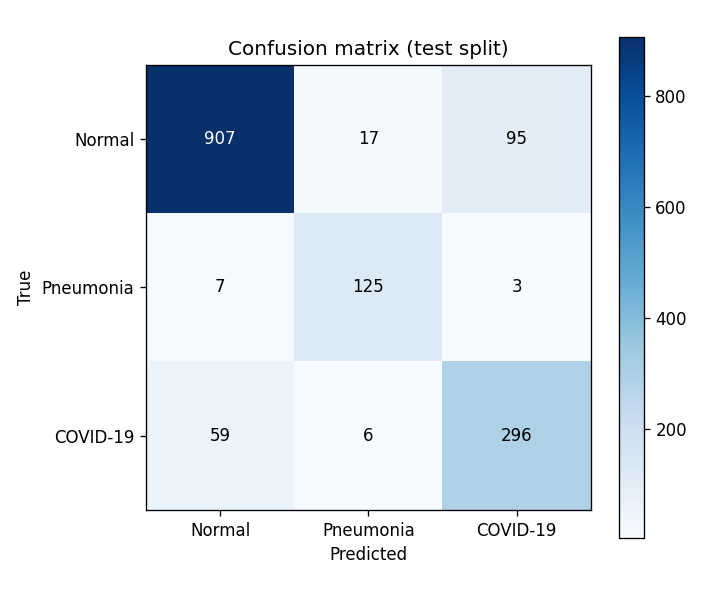

In [10]:
# Mostrar la matriz de confusión
from IPython.display import Image, display

matriz_path = PROJECT_ROOT / 'docs' / 'model-evaluation' / 'confusion_matrix.png'
if matriz_path.exists():
    display(Image(filename=str(matriz_path)))
else:
    print('Matriz no encontrada')

### Ver la arquitectura en directo

Si TensorFlow está instalado en el entorno, la siguiente celda construye el modelo y muestra **la arquitectura completa con `model.summary()`**: las 14 capas, el número de parámetros de cada una, y la forma de la salida en cada paso de la cascada espacial 224 → 112 → 56 → 28 → 14.

In [11]:
# Mostrar la arquitectura: 14 capas leidas del codigo fuente.
# No requiere TensorFlow — extrae las capas directamente de src/ml/model.py.
import re

model_py = PROJECT_ROOT / 'src' / 'ml' / 'model.py'
texto = model_py.read_text()

# Extraer el bloque keras.Sequential([ ... ])
inicio = texto.find('keras.Sequential')
fin = texto.find('],', inicio)
bloque = texto[inicio:fin]

# Cada capa es un layers.X(...) o keras.Input(...)
patron = re.compile(r'(?:layers\.|keras\.)([A-Z]\w+)\(([^)]+)\)')

print(f'{"#":>3}  {"Capa":<18}  {"Configuracion":<55}  Forma salida')
print('-' * 100)

forma = '(224, 224, 1)'
def reducir_pool(f):
    h, w, c = eval(f) if f.count(',') == 2 else (None, None, None)
    return f'({h//2}, {w//2}, {c})' if h else '?'

filas = []
filtros_actuales = None
for i, m in enumerate(patron.finditer(bloque), 1):
    capa, args = m.group(1), m.group(2).strip()
    if capa == 'Input':
        nueva_forma = '(224, 224, 1)'
        config = 'shape=(224, 224, 1)'
    elif capa == 'Conv2D':
        # ej: 32, 3, padding="same", activation="relu"
        partes = [p.strip() for p in args.split(',')]
        filtros = partes[0]
        kernel = partes[1] if len(partes) > 1 else '3'
        filtros_actuales = int(filtros)
        # Conv2D padding=same no cambia HxW, solo profundidad
        h, w, _ = eval(forma)
        nueva_forma = f'({h}, {w}, {filtros})'
        config = f'{filtros} filtros, kernel {kernel}x{kernel}, padding=same, ReLU'
    elif capa == 'MaxPooling2D':
        h, w, c = eval(forma)
        nueva_forma = f'({h//2}, {w//2}, {c})'
        config = 'pool 2x2'
    elif capa == 'Dropout':
        rate = args.split(',')[0]
        nueva_forma = forma
        config = f'rate={rate}'
    elif capa == 'Flatten':
        h, w, c = eval(forma)
        nueva_forma = f'({h*w*c},)'
        config = 'aplana a vector'
    elif capa == 'Dense':
        unidades = args.split(',')[0]
        nueva_forma = f'({unidades},)'
        if 'softmax' in args:
            config = f'{unidades} neuronas + softmax (salida final)'
        else:
            config = f'{unidades} neuronas + ReLU'
    else:
        nueva_forma = forma
        config = args[:50]

    filas.append((i, capa, config, nueva_forma))
    forma = nueva_forma

for i, capa, config, salida in filas:
    print(f'{i:>3}  {capa:<18}  {config:<55}  {salida}')

print()
print(f'TOTAL: {len(filas)} capas')
print(f'Cascada espacial: 224 -> 112 -> 56 -> 28 -> 14')
print(f'Filtros por bloque: 32 -> 64 -> 128 -> 128')
print()
print('Si TF esta instalado, podemos cargar el modelo real:')
try:
    from src.ml.model import build_model
    modelo = build_model()
    print(f'\nTotal parametros del modelo: {modelo.count_params():,}')
    print(f'Modelo serializado: data/models/radiography_classifier.keras (21 MB)')
except Exception as e:
    print(f'  (TensorFlow no disponible en este entorno: {type(e).__name__})')
    print(f'  El modelo entrenado vive en: data/models/radiography_classifier.keras (21 MB)')


  #  Capa                Configuracion                                            Forma salida
----------------------------------------------------------------------------------------------------
  1  Sequential          [
            keras.Input(shape=input_shape, name=       (224, 224, 1)
  2  Conv2D              32 filtros, kernel 3x3, padding=same, ReLU               (224, 224, 32)
  3  MaxPooling2D        pool 2x2                                                 (112, 112, 32)
  4  Conv2D              64 filtros, kernel 3x3, padding=same, ReLU               (112, 112, 64)
  5  MaxPooling2D        pool 2x2                                                 (56, 56, 64)
  6  Conv2D              128 filtros, kernel 3x3, padding=same, ReLU              (56, 56, 128)
  7  MaxPooling2D        pool 2x2                                                 (28, 28, 128)
  8  Conv2D              128 filtros, kernel 3x3, padding=same, ReLU              (28, 28, 128)
  9  MaxPooling2D        pool 2x2 

### Cómo leer la matriz de confusión

- **Filas** = lo que era realmente (verdad de referencia)
- **Columnas** = lo que predijo el modelo
- **Diagonal** = aciertos

**La celda más importante**: la esquina inferior izquierda → **59 COVID marcados como Normal**.  
Son los **contagiosos que se escapan**, el error más grave clínicamente. Por eso introdujimos la regla del slide siguiente.

---
## 6. La regla `covid_threshold_0.35`

### El problema

El modelo con `argmax` puro ("gana el % más alto") era **demasiado tímido** detectando COVID. Se le escapaban **110 de cada 361 enfermos reales** (recall 0,695).

### La solución

Una regla **post-hoc** sobre las probabilidades del modelo (sin reentrenar):

```python
if P(COVID-19) >= 0.35:
    return "COVID-19"
else:
    return argmax(Normal, Pneumonia)
```

**Es como bajar el listón del detector de humo**: salta antes, pillamos más fuegos reales. A cambio, alguna falsa alarma.

### Resultado

| Métrica | Sin regla (argmax) | Con regla 0,35 | Cambio |
|---|---|---|---|
| Acierto general | 0,8719 | 0,8766 | +0,5 pp |
| COVID detectados (recall) | 0,6953 | **0,8199** | **+12,5 pp** |
| Precisión COVID | 0,8071 | 0,7513 | −5,6 pp |
| **Contagiosos que se escapan** | 110 / 361 | **65 / 361** | **−45 casos** |

### Por qué 0,35 y no otro umbral

Probamos 3 valores sobre el split de **validación** (no test, para no contaminar):

- **0,30**: demasiado agresivo, la precisión cae a 71%
- **0,40**: mejora marginal (recall solo sube a 76%)
- **0,35**: el mejor balance → **elegido**

Formalizado en **ADR-010**.

In [12]:
# Ver la regla EN EL CÓDIGO REAL
predictor_path = PROJECT_ROOT / 'src' / 'ml' / 'predictor.py'
lineas = predictor_path.read_text().splitlines()

print('=== src/ml/predictor.py — líneas 33-34 (la constante) ===')
for i in range(32, 35):
    print(f'{i+1:4d}  {lineas[i]}')

print('\n=== src/ml/predictor.py — líneas 109-114 (la regla) ===')
for i in range(108, 115):
    print(f'{i+1:4d}  {lineas[i]}')

=== src/ml/predictor.py — líneas 33-34 (la constante) ===
  33  COVID_THRESHOLD = 0.35
  34  DECISION_RULE = f"covid_threshold_{COVID_THRESHOLD:.2f}"
  35  

=== src/ml/predictor.py — líneas 109-114 (la regla) ===
 109      def _apply_decision_rule(self, probabilities: dict[str, float]) -> str:
 110          """Aplica la regla de decision del umbral COVID sobre las probabilidades softmax raw."""
 111          if probabilities.get(COVID_CLASS, 0.0) >= COVID_THRESHOLD:
 112              return COVID_CLASS
 113          non_covid = {c: p for c, p in probabilities.items() if c != COVID_CLASS}
 114          return max(non_covid, key=non_covid.get)
 115  


In [13]:
# Demostración en vivo: aplicar la regla a probabilidades simuladas
COVID_THRESHOLD = 0.35

def aplicar_regla(prob_normal, prob_pneumonia, prob_covid):
    """Replica la lógica de _apply_decision_rule del predictor."""
    if prob_covid >= COVID_THRESHOLD:
        return 'COVID-19'
    return 'Normal' if prob_normal > prob_pneumonia else 'Pneumonia'

def aplicar_argmax(prob_normal, prob_pneumonia, prob_covid):
    """Lo que hace el argmax puro (sin regla)."""
    probs = {'Normal': prob_normal, 'Pneumonia': prob_pneumonia, 'COVID-19': prob_covid}
    return max(probs, key=probs.get)

casos = [
    ('Caso 1 — radiografía clara COVID',      0.10, 0.05, 0.85),
    ('Caso 2 — duda Normal vs COVID',         0.45, 0.18, 0.37),
    ('Caso 3 — claramente Normal',            0.92, 0.05, 0.03),
    ('Caso 4 — frontera (COVID = umbral)',    0.40, 0.25, 0.35),
    ('Caso 5 — COVID un pelín por debajo',    0.48, 0.18, 0.34),
]

print(f"{'Caso':<40} {'Sin regla (argmax)':<22} {'Con regla 0.35':<20}")
print('─' * 82)
for desc, pn, pp, pc in casos:
    sin = aplicar_argmax(pn, pp, pc)
    con = aplicar_regla(pn, pp, pc)
    cambia = '  ⚠️  CAMBIA' if sin != con else ''
    print(f"{desc:<40} {sin:<22} {con:<20}{cambia}")

Caso                                     Sin regla (argmax)     Con regla 0.35      
──────────────────────────────────────────────────────────────────────────────────
Caso 1 — radiografía clara COVID         COVID-19               COVID-19            
Caso 2 — duda Normal vs COVID            Normal                 COVID-19              ⚠️  CAMBIA
Caso 3 — claramente Normal               Normal                 Normal              
Caso 4 — frontera (COVID = umbral)       Normal                 COVID-19              ⚠️  CAMBIA
Caso 5 — COVID un pelín por debajo       Normal                 Normal              


---
## 7. El triaje por reglas

### Por qué reglas y no ML

**Sin datos reales que copiar, no hay ML honesto.** No tenemos un dataset con la severidad real de cada paciente (nadie nos dijo *"este es grave"*). Si entrenásemos un modelo con etiquetas que nos inventamos, el modelo aprende **nuestras opiniones**, no medicina.

El Máster presenta los **sistemas basados en reglas / reglas de producción** como alternativa legítima cuando faltan datos etiquetados.

Formalizado en **ADR-008**.

### Las reglas (umbrales académicos, no clínicos)

**GRAVE** — basta UNA:
- SpO₂ < 92%
- TA sistólica < 90 mmHg
- Frecuencia respiratoria > 30 rpm
- Frecuencia cardíaca > 130 lpm
- Alteración de conciencia
- Dolor torácico fuerte

**MEDIO** — si NO es grave y se cumple alguna:
- SpO₂ entre 92% y 94%
- Temperatura ≥ 39°C
- Frecuencia respiratoria entre 22 y 30 rpm
- Frecuencia cardíaca entre 110 y 130 lpm
- ≥ 70 años + síntoma respiratorio

**LEVE** — si ninguna salta.

Cada decisión devuelve la **lista de reglas que dispararon** (`reasons`) — explicabilidad directa.

### Si tuviéramos dataset etiquetado, el modelo del temario sería

**`DecisionTreeClassifier`** o **`RandomForestClassifier`** de scikit-learn.  
Un árbol de decisión es matemáticamente equivalente a un conjunto de reglas IF-THEN, solo que los umbrales **se aprenden de datos** en vez de definirlos nosotros.

In [14]:
# Probar el triaje en vivo importando el módulo
from src.api.triage import evaluate

casos = [
    {
        'descripcion': 'Paciente con saturación 85 (típico GRAVE)',
        'payload': {
            'oxygen_saturation': 85, 'systolic_bp': 110,
            'respiratory_rate': 20, 'heart_rate': 95,
            'temperature_celsius': 37.5, 'symptoms': ['tos'],
        }
    },
    {
        'descripcion': 'Anciano con fiebre y tos (típico MEDIO)',
        'payload': {
            'oxygen_saturation': 96, 'systolic_bp': 130,
            'respiratory_rate': 18, 'heart_rate': 80,
            'temperature_celsius': 38.5, 'symptoms': ['tos', 'fiebre'],
            'birth_date': '1945-03-12',
        }
    },
    {
        'descripcion': 'Paciente estable (típico LEVE)',
        'payload': {
            'oxygen_saturation': 98, 'systolic_bp': 120,
            'respiratory_rate': 16, 'heart_rate': 70,
            'temperature_celsius': 36.8, 'symptoms': [],
        }
    },
]

for c in casos:
    resultado = evaluate(c['payload'])
    print(f"{c['descripcion']}")
    print(f"   → Nivel: {resultado.level.upper()}")
    print(f"   → Reglas disparadas: {resultado.reasons if resultado.reasons else '(ninguna)'}\n")

KeyError: 'oxygen_saturation'

---
## 8. La automatización

El enunciado pedía **al menos 1 mecanismo de automatización**. Entregamos **4**. Cada uno funciona de forma distinta — los explico con el "cómo" técnico real.

### Resumen de los 4 mecanismos

| Mecanismo | Qué dispara | Resultado | Dónde vive |
|---|---|---|---|
| **1. Informe diario** | Comando CLI manual | Markdown **idempotente** del día (mismo SHA-256) | `src/automation/daily_report.py` |
| **2. Alertas** | Petición `GET /alerts` | Vista derivada, **cero estado nuevo** | `src/api/alerts.py` |
| **3. Watcher** | Llegada de CSV a `data/incoming/` | Pipeline arranca **solo** | `src/pipeline/watcher.py` |
| **4. Image-ingester** | Bootstrap + watcher | PNG suben a MinIO + se asocian al paciente | `src/pipeline/ingesters/image_ingester.py` |

---

### Mecanismo 1: Informe diario — idempotencia byte-a-byte

Cada día se puede ejecutar:

```bash
python -m src.automation.daily_report
```

**El truco**: si lo ejecuto 2 veces el mismo día, el fichero generado es **idéntico bit a bit** (mismo SHA-256). El cuerpo del Markdown NO contiene `generated_at` — solo contenido determinista de las BBDD.

**Por qué importa**: demuestra que el sistema **no inventa números entre ejecuciones**. Misma fecha → mismo informe → reproducibilidad clínica garantizada.

---

### Mecanismo 2: Alertas — vista derivada (ADR-009)

3 tipos de alertas que **se calculan al pedirlas**, sin tabla nueva:

| Tipo | Cuándo salta |
|---|---|
| `pipeline_failed` | Si el último run del pipeline terminó con error |
| `data_quality_low` | Si el ratio de rechazo supera el 10% en cualquier dimensión |
| `triage_severe` | Si hay pacientes con triaje GRAVE pendientes |

**Flujo**:
```
GET /api/v1/alerts
  → src/api/alerts.py
  → Consulta SQLite (pipeline_runs, quality_summary) + Mongo (triages)
  → Devuelve lista de alertas como JSON
```

**Cero tabla `alerts`**. Cero estado nuevo persistido. Si la situación cambia, la siguiente petición refleja el cambio. **Nunca hay desincronización**.

---

### Mecanismo 3: Watcher — eventos del filesystem

Si dejo un CSV en `data/incoming/`, **el pipeline arranca solo**. Sin clicar, sin ejecutar nada.

Usa la librería `watchdog` (eventos nativos del sistema de archivos, **no polling**):

```
handler.on_created():
  1. Detecta archivo nuevo
  2. Espera a tener AMBOS CSVs (patients + admissions)
  3. Llama al pipeline con esos paths
  4. Mueve los archivos a incoming/processed/
```

Vive en un **container Docker separado** (`hospital-watcher`), con `restart: unless-stopped` por si crashea.

**Demo**: `cp data/raw/patients.csv data/incoming/test.csv` y `docker logs -f hospital-watcher` muestra el pipeline disparándose.

---

### Mecanismo 4: Image-ingester — sube imágenes solo

Las radiografías PNG se suben automáticamente a MinIO y se asocian al paciente:

```
Imagen PNG (ej: HOSP-000042_xray1.png)
  1. Extrae external_id del nombre (HOSP-000042)
  2. Sube binario a MinIO (bucket "radiographies")
  3. Actualiza MongoDB: añade entrada en patients.{external_id}.radiographies
     con metadata (filename, size, sha256, uploaded_at)
```

**Disparador**: durante el bootstrap (al arrancar `docker compose up`) y cada vez que el watcher detecta imágenes nuevas.

---

**Resultado**: el operador deja de mirar logs. El sistema le avisa de lo que requiere atención, en lugar de hacerle buscarlo.

In [15]:
# Pedir las alertas actuales del sistema
import requests

try:
    r = requests.get('http://localhost:8000/api/v1/alerts', timeout=3)
    if r.status_code == 200:
        alertas = r.json()
        print(f'Alertas activas: {len(alertas) if isinstance(alertas, list) else "?"}\n')
        if isinstance(alertas, list):
            for a in alertas[:5]:
                print(f"  · [{a.get('severity', '?').upper():<8}] {a.get('type', '?')} → {a.get('message', '')[:80]}")
        else:
            import json as _j
            print(_j.dumps(alertas, indent=2)[:800])
    else:
        print(f'Status: {r.status_code}')
except Exception as e:
    print(f'Error: {e}')

Alertas activas: ?

{
  "items": [
    {
      "type": "triage_severe",
      "severity": "critical",
      "title": "Paciente triajeado como GRAVE",
      "detail": "reasons=['fc_gt_130']; name=Pancha",
      "source": "patients.triage",
      "source_id": "TRIAGE-20260526-0007",
      "created_at": "2026-05-26T13:11:24.363000"
    }
  ],
  "total": 1,
  "generated_at": "2026-05-26T15:20:04.659346Z",
  "threshold": 0.1,
  "window_start": "2026-05-25T15:20:04.659346Z"
}


### Demostración 1: idempotencia del informe diario

In [16]:
# Demostrar idempotencia del informe diario.
# Lanzamos dentro del container Docker (donde tiene las dependencias completas).
import subprocess, hashlib

def lanzar_y_hashear():
    # Genera el informe dentro del container
    subprocess.run(
        ['docker', 'exec', 'hospital-api', 'python', '-m', 'src.automation.daily_report'],
        capture_output=True, text=True, timeout=30,
    )
    # Lee el archivo desde el container y calcula su sha256
    r = subprocess.run(
        ['docker', 'exec', 'hospital-api', 'sh', '-c',
         'find /app/docs/reports -name "*.md" | tail -1 | xargs sha256sum'],
        capture_output=True, text=True, timeout=10,
    )
    return r.stdout.strip()

print('Ejecucion 1:')
h1 = lanzar_y_hashear()
print('  ' + h1)

print('\nEjecucion 2 (mismo dia, mismas fuentes):')
h2 = lanzar_y_hashear()
print('  ' + h2)

# Comparar
sha1 = h1.split()[0] if h1 else None
sha2 = h2.split()[0] if h2 else None
print()
if sha1 and sha2 and sha1 == sha2:
    print('Resultado: IDEMPOTENTE - mismo SHA-256 en ambas ejecuciones')
    print('   El sistema NO inventa numeros entre ejecuciones.')
else:
    print(f'   sha1={sha1}')
    print(f'   sha2={sha2}')

Ejecucion 1:


  e59327d950c626195cfb09a7192c2d0ad0f3c0d94cee7979ac289a690082847e  /app/docs/reports/2026-05-26.md

Ejecucion 2 (mismo dia, mismas fuentes):


  e59327d950c626195cfb09a7192c2d0ad0f3c0d94cee7979ac289a690082847e  /app/docs/reports/2026-05-26.md

Resultado: IDEMPOTENTE - mismo SHA-256 en ambas ejecuciones
   El sistema NO inventa numeros entre ejecuciones.


### Demostración 2: el código del watcher

In [17]:
# El watcher de filesystem: src/pipeline/watcher.py (primeras 40 lineas)
watcher_py = (PROJECT_ROOT / 'src' / 'pipeline' / 'watcher.py').read_text()
print('\n'.join(watcher_py.split('\n')[:40]))
print(f'\n... ({len(watcher_py.splitlines())} lineas en total)')

"""Vigila un directorio de entrada y dispara el pipeline cuando llegan ambos CSVs.

El watcher es deliberadamente simple: espera hasta que `patients.csv` y
`admissions.csv` esten presentes en el directorio de entrada, llama una
unica vez al callback proporcionado con sus paths, y mueve los archivos a
`incoming/processed/` para que el siguiente batch arranque limpio.

Esto cubre el lado del trigger automatico de RF-7 (el otro lado es un
endpoint manual de la API provisto por T10).
"""
from __future__ import annotations

import shutil
import threading
from collections.abc import Callable
from pathlib import Path

from watchdog.events import FileCreatedEvent, FileSystemEventHandler
from watchdog.observers import Observer

from src.pipeline.logging_config import get_logger

logger = get_logger(__name__)

PATIENTS_FILENAME = "patients.csv"
ADMISSIONS_FILENAME = "admissions.csv"

OnReadyCallback = Callable[[Path, Path], None]


class IncomingFilesWatcher:
    """Vigila `incoming_dir` esperan

### Demostración 3: el image-ingester

In [18]:
# El image-ingester: src/pipeline/ingesters/image_ingester.py (primeras 30 lineas)
ing_py = (PROJECT_ROOT / 'src' / 'pipeline' / 'ingesters' / 'image_ingester.py').read_text()
print('\n'.join(ing_py.split('\n')[:30]))

"""Ingesta imagenes PNG de radiografias de torax a MinIO con metadatos extraidos."""
from __future__ import annotations

import re
from dataclasses import dataclass
from datetime import datetime, timezone
from pathlib import Path

from src.pipeline.logging_config import get_logger
from src.pipeline.storage.minio_client import MinIOClient

logger = get_logger(__name__)

PNG_SIGNATURE = b"\x89PNG\r\n\x1a\n"

# Se espera que los archivos sigan `{patient_external_id}_{suffix}.png`
# donde patient_external_id es HOSP-NNNNNN.
PATIENT_PREFIX_PATTERN = re.compile(r"^(HOSP-\d{6})_")


@dataclass(frozen=True)
class IngestedImage:
    patient_external_id: str
    original_filename: str
    minio_object_key: str
    file_size_bytes: int
    ingested_at: str  # timestamp ISO en UTC


class ImageIngester:


---
## 9. El dashboard

**Lo que ve el operador del hospital cada turno.** Construido con Streamlit, en imagen Docker independiente (ADR-007).

**Es API-only**: no toca MongoDB, SQLite ni MinIO directamente. Solo consume la FastAPI.

### Las 7 vistas

1. **Inicio** — barra crítica, actividad del día
2. **Triaje** — registrar paciente nuevo con signos vitales
3. **Alertas** — las 3 alertas activas, texto humanizado
4. **Pacientes** — buscar y ver detalle
5. **Clasificador** — subir radiografía → predicción
6. **Calidad de datos** — ratios de rechazo + filas rechazadas
7. **Ejecuciones del pipeline** — auditoría de runs

### Si la API se cae

El dashboard **sigue respondiendo** y los chips del sidebar se ponen rojos indicando qué servicio no responde (CA-10 de la spec del dashboard).

**Abre en navegador**: http://localhost:8501

In [19]:
# Listar las 7 vistas
views_dir = PROJECT_ROOT / 'src' / 'dashboard' / 'views'
vistas = sorted([f.stem for f in views_dir.glob('*.py') if f.stem != '__init__'])

print(f'Vistas del dashboard ({len(vistas)}):')
for v in vistas:
    print(f'  · {v}')

Vistas del dashboard (7):
  · alerts
  · classifier
  · overview
  · patients
  · quality
  · runs
  · triage


### Código del frontend — el dashboard es API-only

El dashboard Streamlit **no toca MongoDB, SQLite ni MinIO directamente**. Solo consume la API REST (FastAPI). Esto es clave para defender la **separación de responsabilidades** del ADR-007.

**Arquitectura del dashboard**:

| Archivo | Líneas | Responsabilidad |
|---|---|---|
| `src/dashboard/app.py` | 102 | Entrada del dashboard, router de vistas, sidebar |
| `src/dashboard/api_client.py` | 302 | Cliente HTTP que habla con FastAPI |
| `src/dashboard/config.py` | 24 | Config (URL de la API, etc.) |
| `src/dashboard/views/*.py` | 2.012 | Las 7 vistas (overview, triage, alerts, patients, classifier, quality, runs) |
| `src/dashboard/components/*.py` | 247 | Componentes reutilizables (error_banner, system_status, sidebar) |

**Verificación**: si grepeas `pymongo|sqlite|minio` dentro de `src/dashboard/`, sale vacío. **API-only confirmado**.

In [20]:
# src/dashboard/app.py — entrada del dashboard (las 102 lineas)
app_py = (PROJECT_ROOT / 'src' / 'dashboard' / 'app.py').read_text()
print(app_py)

"""Entrypoint de Streamlit para el dashboard del hospital.

Navegacion en dos bloques (rediseno UX fase 1):

  Operacion         Sistema
  - Inicio          - Calidad de datos
  - Triaje          - Pipeline runs
  - Alertas
  - Pacientes
  - Clasificador

La sidebar usa `st.navigation({...})` con secciones, lo que Streamlit
1.36+ renderiza como cabeceras de grupo. El CSS adicional (microinter-
acciones + tratamiento visual del bloque "Sistema") se inyecta una sola
vez via `inject_sidebar_styles()`.

El footer de la sidebar mantiene los 3 chips de estado del sistema
persistentes en todas las vistas (`render_system_status`).

UI en castellano, sin emojis (convencion ASCII del repo).
"""
from __future__ import annotations

from pathlib import Path

import streamlit as st

from src.dashboard.api_client import ApiClient
from src.dashboard.components.sidebar_styles import inject_sidebar_styles
from src.dashboard.components.system_status import render_system_status
from src.dashboard.config i

**🖼️ Vista Inicio del dashboard — entrada del operador, generada por el `app.py` de arriba**

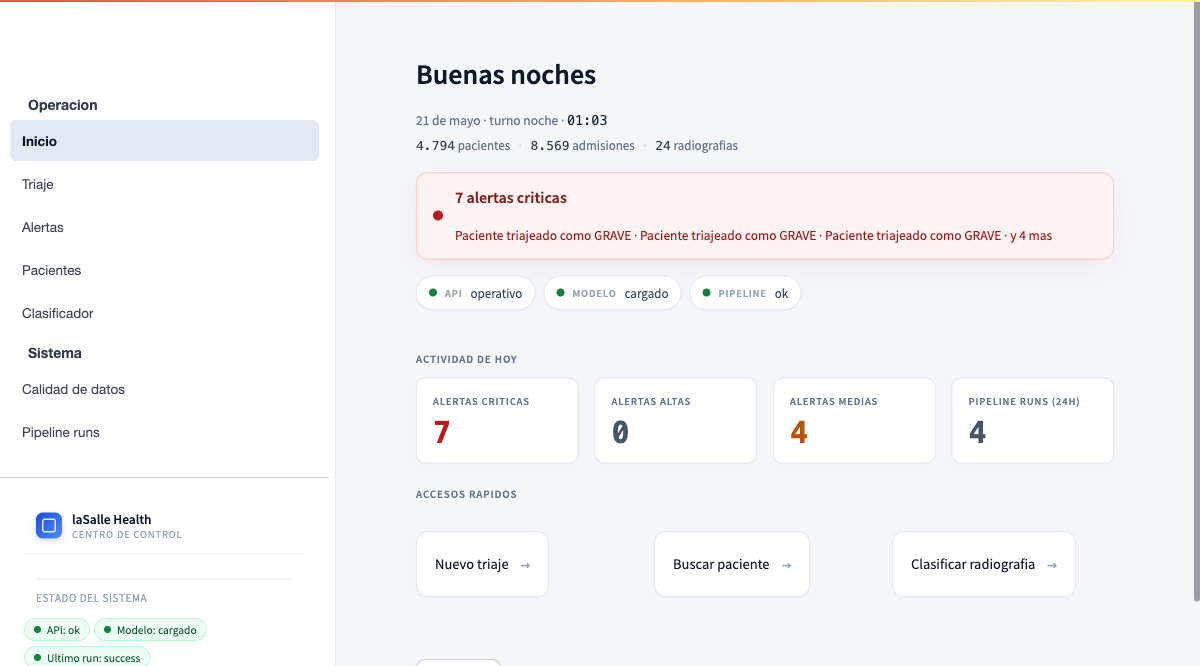

In [21]:
from IPython.display import Image, display, Markdown
display(Markdown('**🖼️ Vista Inicio del dashboard — entrada del operador, generada por el `app.py` de arriba**'))
display(Image(filename=str(PROJECT_ROOT / 'docs' / 'presentation' / 'img' / 'dash-inicio.png'), width=900))

### El cliente HTTP — la prueba del API-only

`api_client.py` centraliza **todas las llamadas a la API**. Cualquier vista que necesite datos pasa por aquí. Si la API se cae, este es el archivo donde se detectan los errores y se devuelven al UI con el banner rojo.

Voy a mostrar solo las primeras 60 líneas (la clase `ApiClient` y sus métodos de health):

In [22]:
# src/dashboard/api_client.py — primeras 60 líneas
api_client = (PROJECT_ROOT / 'src' / 'dashboard' / 'api_client.py').read_text()
lineas = api_client.split('\n')
print('\n'.join(lineas[:60]))
print(f'\n... ({len(lineas) - 60} líneas más)')

"""Wrapper sincrono ligero sobre httpx para el dashboard.

Cada metodo devuelve una tupla `(data, error)`. El error es `None` si
todo va bien, y un `ApiError` en caso contrario. Las vistas nunca
lanzan excepciones — comprueban `error is not None` y renderizan un
banner via `components.error_banner`.

Por que sync + tuple-style:
  * Streamlit re-ejecuta el script en cada interaccion. Async obligaria
    a hacer `asyncio.run()` en cada llamada, pesado y fragil.
  * Devolver `(data, error)` permite leer las vistas de arriba a abajo
    sin `try/except` por todas partes.

`image_bytes` es el unico metodo que devuelve bytes en crudo (contenido
PNG); el resto devuelven JSON ya parseado.
"""
from __future__ import annotations

import logging
from dataclasses import dataclass
from typing import Any, Literal, Optional

import httpx

logger = logging.getLogger(__name__)


ErrorKind = Literal[
    "network",      # connection refused / timeout / DNS
    "not_found",    # HTTP 404
    "validation"

**🖼️ Vista Alertas — uno de los endpoints que más usa `api_client.py`**

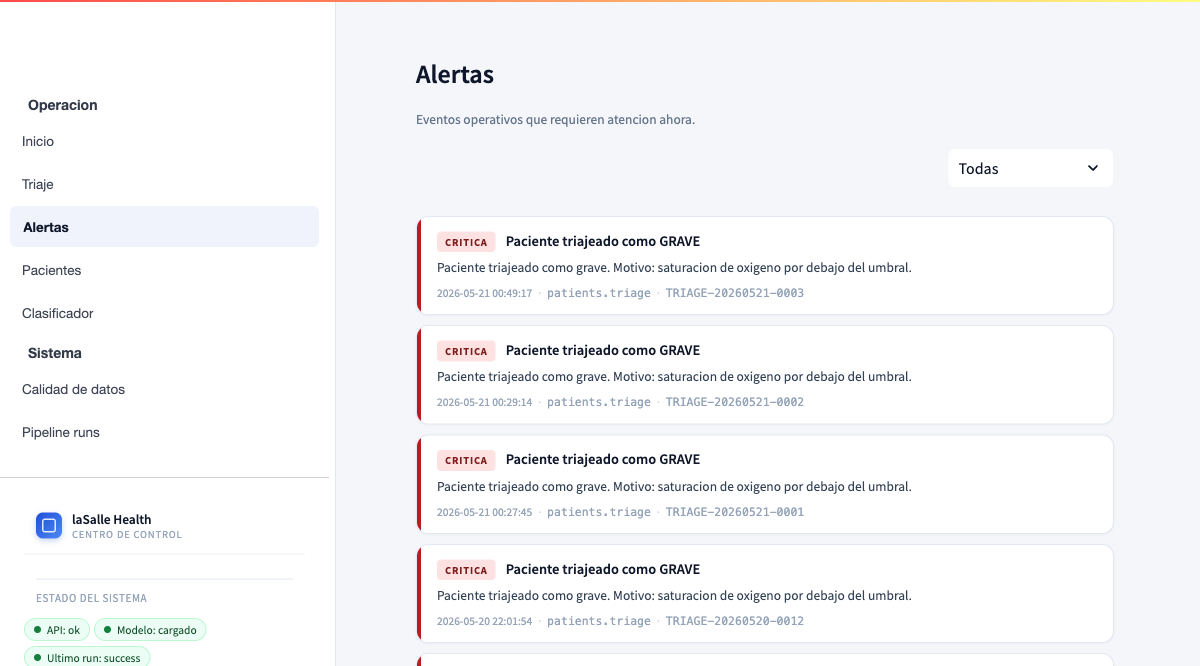

In [23]:
from IPython.display import Image, display, Markdown
display(Markdown('**🖼️ Vista Alertas — uno de los endpoints que más usa `api_client.py`**'))
display(Image(filename=str(PROJECT_ROOT / 'docs' / 'presentation' / 'img' / 'dash-alertas.png'), width=900))

### Una vista de ejemplo — el clasificador

Cada vista del dashboard vive en `src/dashboard/views/`. Son archivos independientes con una función `render()` que Streamlit ejecuta cuando se selecciona esa vista.

Voy a mostrar el header de **classifier.py** (la vista que se usa en la demo de la clasificación COVID):

In [24]:
# src/dashboard/views/classifier.py — primeras 50 líneas
classifier = (PROJECT_ROOT / 'src' / 'dashboard' / 'views' / 'classifier.py').read_text()
print('\n'.join(classifier.split('\n')[:50]))

"""Vista Clasificador (rediseno UX fase 5).

Imagen mas protagonista, resultado claro, detalle del modelo plegado.

Cambios respecto a la version anterior:
  - Imagen full-width arriba (no compartiendo fila con la columna de
    accion). Boton "Clasificar" justo debajo.
  - Resultado simplificado: clase predicha grande + horizontal probs.
    Sin grid de 4 metric (clase / version / regla / cuando) — la
    version, la regla de decision y el timestamp pasan a una linea
    meta debajo.
  - La regla `covid_threshold_*` se muestra de forma legible
    ("Umbral COVID-19: 0.35"), no como id tecnico.
  - Bloque "Tip contextual" y captions tecnicos densos sustituidos
    por una linea breve cuando aplica.
  - Sub-seccion de evaluacion del modelo (recall + matriz de
    confusion) plegada en un expander al final, no abierta por
    defecto.
  - `use_column_width=True` (deprecado en Streamlit reciente)
    sustituido por `use_container_width=True`.

API-only: `list_radiographies`, `health`, `im

**🖼️ Vista Clasificador del dashboard — código de arriba renderizado**

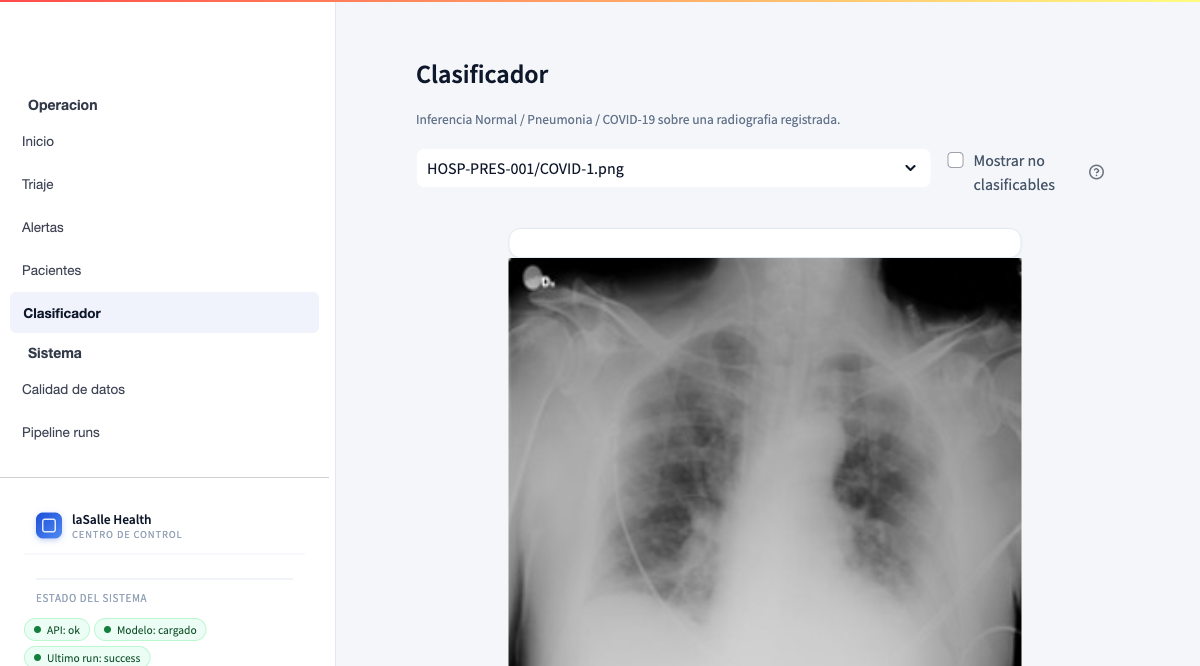

In [25]:
from IPython.display import Image, display, Markdown
display(Markdown('**🖼️ Vista Clasificador del dashboard — código de arriba renderizado**'))
display(Image(filename=str(PROJECT_ROOT / 'docs' / 'presentation' / 'img' / 'dash-clasificador.png'), width=900))

**🖼️ Resultado tras clasificar: COVID-19 con probabilidades + umbral 0,35 aplicado**

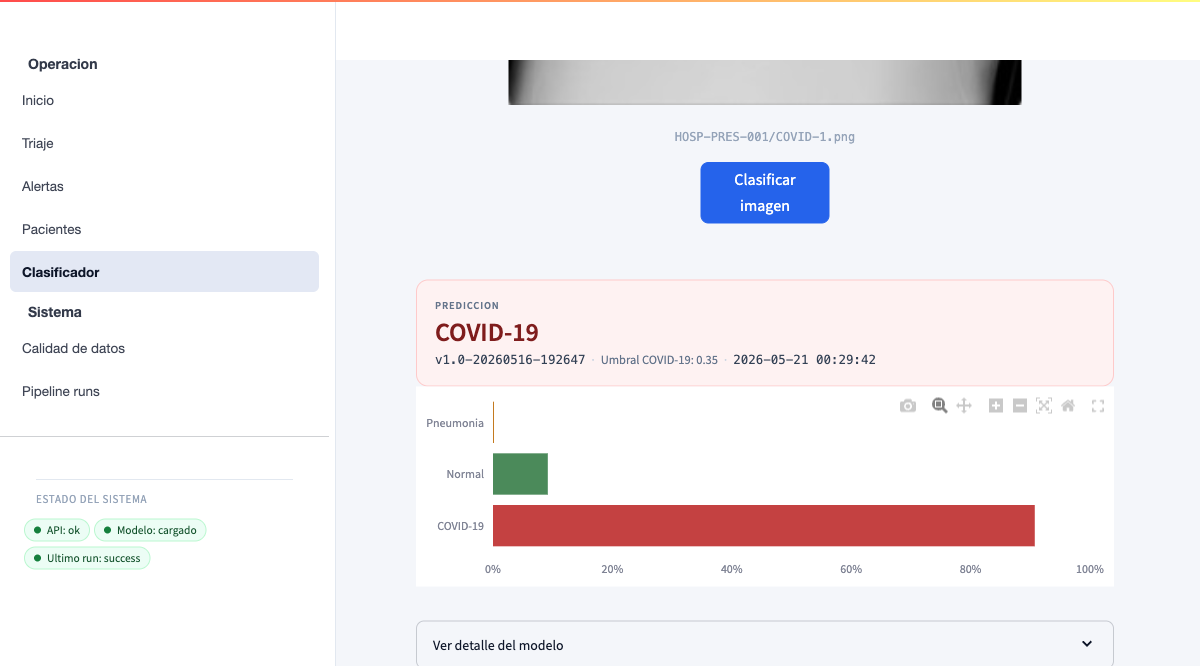

In [26]:
from IPython.display import Image, display, Markdown
display(Markdown('**🖼️ Resultado tras clasificar: COVID-19 con probabilidades + umbral 0,35 aplicado**'))
display(Image(filename=str(PROJECT_ROOT / 'docs' / 'presentation' / 'img' / 'dash-prediccion.png'), width=900))

### Verificación: cero acoplamiento con la persistencia

Si grepeo dentro de `src/dashboard/` los imports de pymongo, sqlite3 o minio, no encuentro ninguno. **El dashboard solo habla con la API**.

In [27]:
# Verificar que NINGUN archivo del dashboard importa pymongo/sqlite3/minio
import subprocess

r = subprocess.run(
    ['grep', '-rE', r'(import pymongo|import sqlite|from pymongo|from sqlite|from minio|import minio)',
     str(PROJECT_ROOT / 'src' / 'dashboard')],
    capture_output=True, text=True
)
salida = r.stdout.strip()
if not salida:
    print('✅ API-only confirmado: 0 imports de capas de persistencia en src/dashboard/')
    print('   El dashboard solo se comunica con la API REST (FastAPI).')
else:
    print('⚠️ Imports encontrados:')
    print(salida)

✅ API-only confirmado: 0 imports de capas de persistencia en src/dashboard/
   El dashboard solo se comunica con la API REST (FastAPI).


**🖼️ Vista Triaje en acción — SpO₂=85 → resultado GRAVE con las reglas que dispararon**

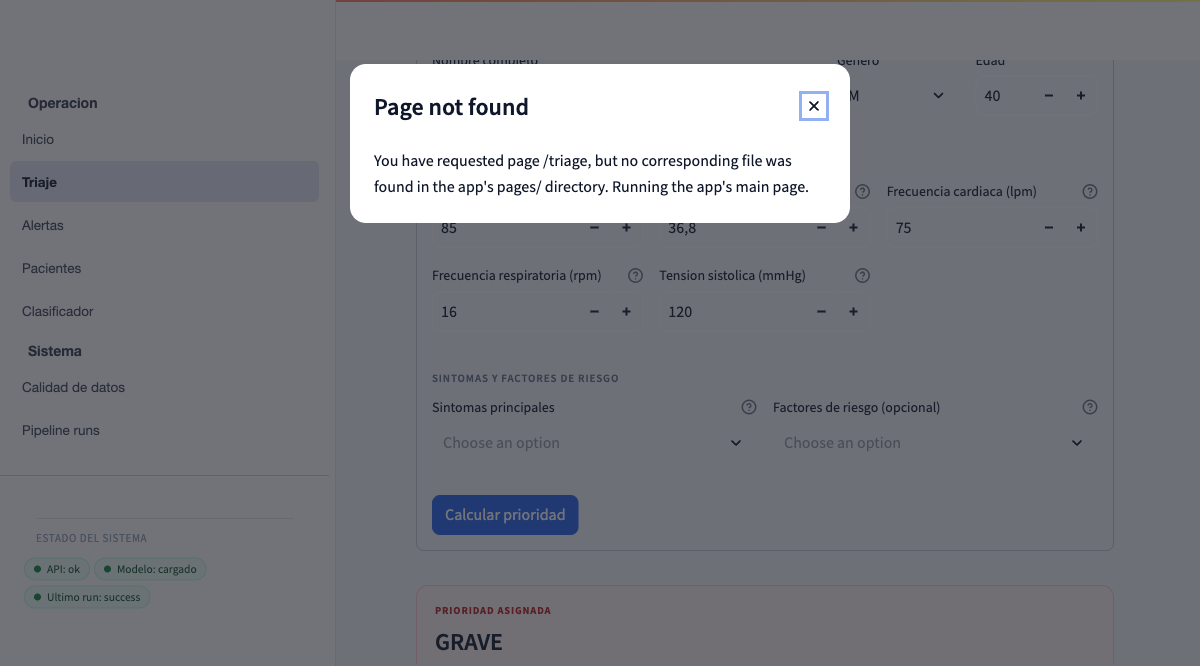

In [28]:
from IPython.display import Image, display, Markdown
display(Markdown('**🖼️ Vista Triaje en acción — SpO₂=85 → resultado GRAVE con las reglas que dispararon**'))
display(Image(filename=str(PROJECT_ROOT / 'docs' / 'presentation' / 'img' / 'dash-triaje-grave.png'), width=900))

---
## 10. Logs y trazabilidad

El sistema tiene **tres niveles de logs**, todos accesibles en vivo:

| Nivel | Dónde está | Para qué |
|---|---|---|
| **Operativos (containers)** | `docker logs -f hospital-api` | Ver peticiones, errores, operaciones en tiempo real |
| **Auditoría del pipeline** | Tabla `pipeline_runs` en SQLite | Cada ejecución del ETL deja huella (timestamp, registros procesados, rechazados, estado) |
| **Entrenamiento del modelo** | `docs/model-evaluation/` | Curva de aprendizaje, métricas por época, matriz de confusión final |

Configuración central de logging: `src/pipeline/logging_config.py`.

### Observabilidad en directo

Cualquier persona que quiera ver el sistema funcionando solo necesita abrir un terminal con:

```bash
docker logs -f hospital-api
```

Cuando se hace una petición al sistema (clasificar imagen, registrar triaje, etc.), las peticiones aparecen en directo en ese log. **El sistema queda visible en tiempo real.**

In [29]:
# Auditoría del pipeline: cada ejecución del ETL queda registrada en SQLite
import requests, json

try:
    r = requests.get('http://localhost:8000/api/v1/pipeline/runs', timeout=3)
    if r.status_code == 200:
        data = r.json()
        items = data.get('items', []) if isinstance(data, dict) else data
        total = data.get('total', len(items)) if isinstance(data, dict) else len(items)
        print(f'Total ejecuciones registradas en SQLite: {total}\n')
        print(f"{'Fecha':<22}  {'Trigger':<14}  {'Estado':<10}  {'Procesados':>10}  {'Rechazados':>10}")
        print('-' * 80)
        for run in items[:8]:
            inicio = (run.get('started_at') or '')[:19]
            trigger = run.get('trigger_type', '?')[:12]
            estado = run.get('status', '?')
            procesados = run.get('records_processed', 0)
            rechazados = run.get('records_rejected', 0)
            print(f"{inicio:<22}  {trigger:<14}  {estado:<10}  {procesados:>10,}  {rechazados:>10,}")
    else:
        print(f'Status: {r.status_code}')
except Exception as e:
    print(f'Error: {e}')

Total ejecuciones registradas en SQLite: 8

Fecha                   Trigger         Estado      Procesados  Rechazados
--------------------------------------------------------------------------------
2026-05-21T00:49:08     e2e-test        success         13,314       1,692
2026-05-20T22:01:47     e2e-test        success         13,314       1,692
2026-05-20T21:59:02     e2e-test        success         13,314       1,692
2026-05-20T11:28:03     e2e-test        success         13,314       1,692
2026-05-19T07:04:47     e2e-test        success         13,314       1,692
2026-05-19T07:01:51     e2e-test        success         13,314       1,692
2026-05-19T06:40:35     e2e-test        success         13,314       1,692
2026-05-18T13:41:27     bootstrap       success         13,314       1,692


In [30]:
# Últimas 15 líneas del log del API container
import subprocess

try:
    r = subprocess.run(
        ['docker', 'logs', '--tail', '15', 'hospital-api'],
        capture_output=True, text=True, timeout=5
    )
    print('=== docker logs --tail 15 hospital-api ===\n')
    output = (r.stdout + r.stderr).strip()
    if output:
        print(output)
    else:
        print('(sin actividad reciente)')
except Exception as e:
    print(f'No se pudo leer el log del container: {e}')
    print('(El comando funciona si los containers Docker están levantados)')

=== docker logs --tail 15 hospital-api ===

INFO:     192.168.65.1:50918 - "GET /docs HTTP/1.1" 200 OK
INFO:     192.168.65.1:18442 - "GET /api/v1/pipeline/quality-summary HTTP/1.1" 200 OK
INFO:     192.168.65.1:21176 - "GET /api/v1/alerts HTTP/1.1" 200 OK
INFO:     192.168.65.1:64700 - "GET /api/v1/pipeline/runs HTTP/1.1" 200 OK
INFO:     127.0.0.1:49132 - "GET /api/v1/health HTTP/1.1" 200 OK
INFO:     127.0.0.1:34384 - "GET /api/v1/health HTTP/1.1" 200 OK
INFO:     127.0.0.1:45910 - "GET /api/v1/health HTTP/1.1" 200 OK
INFO:     127.0.0.1:35020 - "GET /api/v1/health HTTP/1.1" 200 OK
INFO:     127.0.0.1:34790 - "GET /api/v1/health HTTP/1.1" 200 OK
INFO:     127.0.0.1:36450 - "GET /api/v1/health HTTP/1.1" 200 OK
INFO:     192.168.65.1:45446 - "GET /api/v1/health HTTP/1.1" 200 OK
INFO:     192.168.65.1:49105 - "GET /docs HTTP/1.1" 200 OK
INFO:     192.168.65.1:51869 - "GET /api/v1/pipeline/quality-summary HTTP/1.1" 200 OK
INFO:     192.168.65.1:56201 - "GET /api/v1/alerts HTTP/1.1" 200 

### Logs de entrenamiento del modelo

En [`docs/model-evaluation/`](../docs/model-evaluation/) tenemos los artefactos del entrenamiento — **todo reproducible**:

| Archivo | Contenido |
|---|---|
| `training_log.csv` | Métricas época por época (loss, accuracy, val_loss, val_accuracy) |
| `learning_curves.png` | Gráfico visual del entrenamiento |
| `confusion_matrix.png` | Matriz de confusión sobre el split de test |
| `metrics.json` | Métricas finales (accuracy, macro_f1, per_class) |
| `report.md` | Reporte completo de la evaluación |
| `threshold-analysis.md` | Comparativa de los 3 umbrales probados (0.30 / 0.35 / 0.40) |

In [31]:
# Resumen del training_log.csv (las primeras y últimas épocas)
import pandas as pd

log_path = PROJECT_ROOT / 'docs' / 'model-evaluation' / 'training_log.csv'
if log_path.exists():
    df_log = pd.read_csv(log_path)
    print(f'Épocas entrenadas: {len(df_log)}')
    print(f'Columnas: {list(df_log.columns)}\n')

    print('Primeras 3 épocas:')
    print(df_log.head(3).to_string(index=False))

    print('\nÚltimas 3 épocas (EarlyStopping activado al final):')
    print(df_log.tail(3).to_string(index=False))
else:
    print(f'No encontrado: {log_path}')

Épocas entrenadas: 35
Columnas: ['epoch', 'accuracy', 'loss', 'val_accuracy', 'val_loss']

Primeras 3 épocas:
 epoch  accuracy     loss  val_accuracy  val_loss
     0  0.660810 0.758950      0.672607  0.995688
     1  0.672193 0.750031      0.672607  0.922053
     2  0.672771 0.750632      0.672607  0.880723

Últimas 3 épocas (EarlyStopping activado al final):
 epoch  accuracy     loss  val_accuracy  val_loss
    32  0.747917 0.520408      0.881188  0.277026
    33  0.750887 0.519023      0.883168  0.277957
    34  0.752949 0.519558      0.881848  0.270983


---
## 11. Tests automatizados

El proyecto tiene una **suite de tests** que verifica el comportamiento del sistema en cada cambio. Sigue el principio TDD del SDD Kit: cada criterio de aceptación de las specs tiene su test.

### Categorías de tests

| Carpeta | Qué cubre |
|---|---|
| `tests/api/` | Endpoints REST (FastAPI): clasificación, triaje, alertas, pacientes, pipeline |
| `tests/ml/` | Modelo CNN: arquitectura, predictor, regla de decisión `covid_threshold_0.35` |
| `tests/pipeline/` | Pipeline PySpark: ingesters, processors (validator, cleaner, transformer), storage |
| `tests/automation/` | Informe diario (idempotencia byte-a-byte) |
| `tests/dashboard/` | Componentes del dashboard (estado del sistema, error banner) |

### Cómo se ejecutan

```bash
pytest tests/                # toda la suite
pytest tests/ml/ -v          # solo ML, con detalle
pytest -k threshold          # solo los que prueban la regla 0.35
```

In [32]:
# Contar tests en cada categoría
from pathlib import Path

categorias = ['api', 'ml', 'pipeline', 'automation', 'dashboard']
print(f'{"Categoria":<14}  {"Archivos":>10}  {"Funciones test":>14}')
print('-' * 45)

total_files = 0
total_funcs = 0
for cat in categorias:
    cat_dir = PROJECT_ROOT / 'tests' / cat
    if not cat_dir.exists():
        continue
    archivos = list(cat_dir.rglob('test_*.py'))
    funcs = 0
    for f in archivos:
        contenido = f.read_text()
        # contar definiciones que empiecen por 'def test_'
        funcs += contenido.count('\ndef test_') + (1 if contenido.startswith('def test_') else 0)
    total_files += len(archivos)
    total_funcs += funcs
    print(f'{cat:<14}  {len(archivos):>10}  {funcs:>14}')

print('-' * 45)
print(f'{"TOTAL":<14}  {total_files:>10}  {total_funcs:>14}')

Categoria         Archivos  Funciones test
---------------------------------------------
api                     14             122
ml                       7              51
pipeline                15             130
automation               1               6
dashboard                3              48
---------------------------------------------
TOTAL                   40             357


In [33]:
# Lanzar UNA muestra rápida: tests del predictor (la regla 0.35)
import subprocess

print('Ejecutando: pytest tests/ml/test_predictor.py -v --tb=no -q\n')
try:
    r = subprocess.run(
        ['python3', '-m', 'pytest', 'tests/ml/test_predictor.py', '-v', '--tb=no', '-q', '--no-header'],
        capture_output=True, text=True, timeout=60, cwd=str(PROJECT_ROOT)
    )
    # imprimir las últimas líneas (resumen)
    out = (r.stdout + r.stderr).strip().split('\n')
    for linea in out[-30:]:
        print(linea)
except Exception as e:
    print(f'No se pudo ejecutar pytest aquí: {e}')
    print('(Lanzar desde terminal: pytest tests/ml/test_predictor.py -v)')

Ejecutando: pytest tests/ml/test_predictor.py -v --tb=no -q



============================= test session starts ==============================
collected 0 items / 1 skipped

============================== 1 skipped in 0.06s ==============================


---
## 12. Ética y limitaciones — sin maquillaje

### Posición ética

- **Datos inventados** con Faker. Cero datos reales de pacientes.
- Dataset Kaggle: usamos la licencia **que el autor publica**, no asumimos genérica.
- **Ayudamos al médico, NO le sustituimos**. La decisión clínica sigue siendo humana.

### Lo que NO hace el sistema

1. **Aún se escapan 65 enfermos de COVID** de cada 361 reales (recall 0,820). El sistema falla en el 18% de los positivos.
2. Si le metes una foto que **NO es radiografía de tórax**, devuelve una clase igual con confianza arbitraria.
3. **No muestra qué zona** de la imagen ha mirado para decidir (interpretabilidad — Grad-CAM es trabajo futuro).
4. **Sin login, sin copia de seguridad, sin alta disponibilidad**.
5. Los **umbrales del triaje son académicos**, no validados por médicos.

### Dónde NO usaríamos este sistema sin cambios serios

- Decisiones clínicas que afecten al paciente
- Hospitales con datos reales (PII)
- Entornos que exijan disponibilidad 24/7
- Sin certificación CE/FDA

Documentado en el **capítulo 14 de la memoria técnica**.

---
## 13. Trabajo futuro

Si este proyecto se convirtiera en un producto real, **el camino claro** es:

1. **Transfer learning** con DenseNet/EfficientNet preentrenados sobre imágenes médicas (CheXNet). Estimación: recall COVID por encima de **0,90**.
2. **Grad-CAM por defecto** en cada predicción → enseñar qué zona miró el modelo.
3. **Detección de imágenes fuera del dominio** (clasificador binario previo "¿es radiografía?").
4. **Alertas con histórico auditable** (reabrir ADR-009 si el cliente lo necesita).
5. **Validación clínica de los umbrales del triaje** con personal sanitario.
6. **Certificación CE/FDA** si llegara a uso clínico real.

Documentado en el **capítulo 17 de la memoria técnica**.

---

## Conclusión

> Lo que entregamos hoy es una **base sólida, honesta y reproducible** sobre la que se construye un sistema sanitario real.  
> En consultoría en salud, esa honestidad — saber exactamente para qué sirve un sistema y para qué no — vale más que vender humo.

### Las cifras clave

| Cifra | Significado |
|---|---|
| **0,8766** | Acierto general (87,7 de cada 100 bien) |
| **0,8199** | COVID detectados de los reales con la regla |
| **+45** | Contagiosos pillados más con la regla |
| **65 / 361** | COVID que aún se escapan |
| **417 + 1** | Tests verdes |
| **15.150** | Imágenes en el dataset (12.120 train) |
| **6 specs · 10 ADRs · 31 sesiones IA** | Metodología SDD |
| **< 1 min** | Arranque del sistema completo |

**Gracias.**